<a href="https://colab.research.google.com/github/BhanuPratapSingh16/Weather-GAN/blob/main/WeatherGAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
!pip install opendatasets --quiet

In [26]:
import opendatasets as od

In [27]:
od.download("https://www.kaggle.com/datasets/shuvoalok/cityscapes")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: kakkarot
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/shuvoalok/cityscapes


100%|██████████| 199M/199M [00:00<00:00, 273MB/s]


In [173]:
od.download("https://www.kaggle.com/datasets/mitanshuchakrawarty/new-idd-dataset")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: kakarot
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/mitanshuchakrawarty/new-idd-dataset


100%|██████████| 2.79G/2.79G [00:17<00:00, 173MB/s]


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
p1 = "/content/cityscapes/train/img"
p2 = "/content/new-idd-dataset/IDD_RESIZED/image_archive"
target = "/content/drive/MyDrive/datasets/Weather"

# Generate synthetic dataset for different weather conditions

## Fog

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import os
from torchvision.datasets import ImageFolder
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import cv2
import cupy as cp
import random

In [3]:
data_dir = "/content/drive/MyDrive/datasets/Weather Dataset"
clear_weather_dir = os.path.join(data_dir, "Clear")
fog_weather_dir = os.path.join(data_dir, "Fog")

In [24]:
class FogAugmentation:
    def __init__(self):
        self.min_trans = 0.4
        self.max_trans = 0.75
        self.intensity = (self.min_trans, self.max_trans)

    def generate_depth_map(self, h, w):
        depth = cp.linspace(0, 1, h).reshape(-1, 1)
        depth = cp.tile(depth, (1, w))
        return depth

    def apply_fog(self, image):
        img = cp.array(image, dtype=cp.float32) / 255.0
        h, w = img.shape[:2]

        depth_map = cp.asarray(self.generate_depth_map(h, w))
        transmission = self.min_trans + depth_map * (self.max_trans - self.min_trans)
        transmission = cp.clip(transmission, 0, 1)

        # Expand transmission to 3 channels
        if len(transmission.shape) == 2:
            transmission = transmission[:, :, cp.newaxis]

        # Determine atmospheric light
        flat_img = img.reshape(-1, 3)
        intensity = cp.sum(flat_img, axis=1)
        brightest_idx = cp.argmax(intensity)
        atmospheric_light = flat_img[brightest_idx]
        atmospheric_light = atmospheric_light * 0.6 + cp.array([0.85, 0.85, 0.85]) * 1.1
        # atmospheric_light = cp.clip(atmospheric_light, 0, 1)

        atmospheric_light = cp.array(atmospheric_light)
        # Apply atmospheric scattering model
        foggy_img = img * transmission + atmospheric_light * (1 - transmission)
        foggy_img = cp.clip(foggy_img, 0, 1)

        # Transfer back to CPU
        result = cp.asnumpy(foggy_img * 255).astype(np.uint8)

        return result


In [48]:
import time

def process_images(input_dir, output_dir):
    image_files = os.listdir(input_dir)

    total_images = len(image_files)
    print(f"Found {total_images} images to process")

    processed = 0

    start_time = time.time()

    for img_file in image_files:
        stem, ext = tuple(img_file.split("."))
        img_file = os.path.join(input_dir, img_file)
        img = cv2.imread(str(img_file))
        if img is None:
            print(f"Warning: Could not read {img_file}")
            continue

        fog_aug = FogAugmentation()
        # Generate clean foggy version (no particles)
        foggy = fog_aug.apply_fog(img)

        # Save with intensity in filename
        output_file = os.path.join(output_dir, f"{stem}.{ext}")
        cv2.imwrite(str(output_file), foggy)

        processed += 1

        # Progress update every 100 images
        if processed % 100 == 0:
            elapsed = time.time() - start_time
            rate = processed / elapsed
            remaining = (total_images - processed) / rate
            print(f"Processed: {processed}/{total_images} ({processed/total_images*100:.1f}%) "
                  f"| Rate: {rate:.1f} img/s")

    total_time = time.time() - start_time
    final_rate = processed / total_time


In [ ]:
process_images(clear_weather_dir, fog_weather_dir)

In [23]:
class RainAugmentation:
    def __init__(self):
        self.num_streaks = 1300
        self.streak_length = (40, 60)
        self.haze = 0.45
        self.wetness = 0.7

    def generate_rain_streaks(self, h, w, angle=-10):
        rain_layer = cp.zeros((h, w), dtype=cp.float32)

        x_pos = cp.random.randint(0, w, self.num_streaks)
        y_pos = cp.random.randint(0, h, self.num_streaks)
        length = cp.random.randint(*self.streak_length, self.num_streaks)
        intensity = cp.random.uniform(0.5, 2, self.num_streaks)

        rain_np = cp.asnumpy(rain_layer)
        x_pos_np = cp.asnumpy(x_pos)
        y_pos_np = cp.asnumpy(y_pos)
        length_np = cp.asnumpy(length)
        intensity_np = cp.asnumpy(intensity)

        angle_rad = np.radians(angle)
        dx = int(np.cos(angle_rad + np.pi/2))
        dy = int(np.sin(angle_rad + np.pi/2))

        for i in range(self.num_streaks):
            x1 = int(x_pos_np[i])
            y1 = int(y_pos_np[i])
            length = int(length_np[i])

            x2 = x1 + dx * length
            y2 = y1 + dy * length

            if 0 <= x1 < w and 0 <= y1 < h and 0 <= x2 < w and 0 <= y2 < h:
                cv2.line(rain_np, (x1, y1), (x2, y2), float(intensity_np[i]), thickness=1, lineType=cv2.LINE_AA)

        kernel_size = max(3, self.streak_length[0] // 3)
        if kernel_size % 2 == 0:
            kernel_size += 1
        rain_np = cv2.GaussianBlur(rain_np, (1, kernel_size), 0)

        return cp.array(rain_np)

    def apply_rain(self, image):
        img = cp.array(image, dtype=cp.float32) / 255.0
        h, w = img.shape[:2]

        rain_streaks = self.generate_rain_streaks(h, w)
        rain_streaks = rain_streaks[:, :, cp.newaxis]

        atmospheric_light = cp.array([0.85, 0.85, 0.85], dtype=cp.float32)
        transmission = 1 - self.haze
        img = img * transmission + atmospheric_light * (1 - transmission)

        rain_color = cp.array([0.85, 0.9, 0.9], dtype=cp.float32)  # Slightly blue-white
        img = img + rain_streaks * rain_color * 0.8

        img = img * (1 - self.wetness)
        mean = cp.mean(img, axis=(0, 1), keepdims=True)
        img = mean + (img - mean) * (1 + self.wetness)

        img = cp.clip(img, 0, 1)

        result = cp.asnumpy(img * 255).astype(np.uint8)

        return result

In [ ]:
rain_dir = os.path.join(data_dir, "Rain")

In [162]:
img_path = "/content/cityscapes/val/img/val125.png"
# img_path = os.path.join(clear_weather_dir, img_path)
img = cv2.imread(img_path)

rain_aug = RainAugmentation()
rain_img = rain_aug.apply_rain(img)

cv2.imwrite("rain_img.jpg", rain_img)

True

In [ ]:
import time

def process_images(input_dir, output_dir):
    image_files = os.listdir(input_dir)

    total_images = len(image_files)
    print(f"Found {total_images} images to process")

    processed = 0

    start_time = time.time()

    for img_file in image_files:
        stem, ext = tuple(img_file.split("."))
        img_file = os.path.join(input_dir, img_file)
        img = cv2.imread(str(img_file))
        if img is None:
            print(f"Warning: Could not read {img_file}")
            continue

        rain_aug = RainAugmentation()
        # Generate clean foggy version (no particles)
        rainy = rain_aug.apply_rain(img)

        # Save with intensity in filename
        output_file = os.path.join(output_dir, f"{stem}.{ext}")
        cv2.imwrite(str(output_file), rainy)

        processed += 1

        # Progress update every 100 images
        if processed % 100 == 0:
            elapsed = time.time() - start_time
            rate = processed / elapsed
            remaining = (total_images - processed) / rate
            print(f"Processed: {processed}/{total_images} ({processed/total_images*100:.1f}%) "
                  f"| Rate: {rate:.1f} img/s")

    total_time = time.time() - start_time
    final_rate = processed / total_time

In [ ]:
process_images(clear_weather_dir, rain_dir)

In [2]:
transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [6]:
data_dir = "/content/drive/MyDrive/datasets/Weather Dataset"
clear_weather_dir = os.path.join(data_dir, "Clear")
fog_weather_dir = os.path.join(data_dir, "Fog")
rain_weather_dir = os.path.join(data_dir, "Rain")

In [7]:
len(os.listdir(clear_weather_dir)), len(os.listdir(fog_weather_dir)), len(os.listdir(rain_weather_dir))

(9969, 9968, 9968)

In [8]:
class ImageDataset(Dataset):
    def __init__(self, dir, transforms=None):
        self.dir = dir
        self.transforms = transforms
        self.clear_images = os.listdir(dir)
        self.clear_images = [os.path.join(dir, img) for img in self.clear_images]

        self.images = []
        for img in self.clear_images:
            sample = {"clear": img}
            fog_img = img.replace("Clear", "Fog")
            rain_img = img.replace("Clear", "Rain")
            if os.path.exists(fog_img):
                sample["fog"] = fog_img
            if os.path.exists(rain_img):
                sample["rain"] = rain_img
            if os.path.exists(fog_img) and os.path.exists(rain_img):
                self.images.append(sample)

        self.images = self.images[:4000]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        sample = self.images[idx]

        clear_img = Image.open(sample["clear"]).convert("RGB")
        if self.transforms:
            clear_img = self.transforms(clear_img)

        weather_type = random.choice(["fog", "rain"])
        weather_img = Image.open(sample[weather_type]).convert("RGB")
        if self.transforms:
            weather_img = self.transforms(weather_img)

        weather_map = torch.ones(1, clear_img.shape[1], clear_img.shape[2])
        weather_map *= 0 if weather_type == "fog" else 1
        return {"clear": clear_img, "weather": weather_img, "weather_map": weather_map}

In [9]:
dataset = ImageDataset(clear_weather_dir, transforms)

In [11]:
dataloader = DataLoader(dataset, batch_size=8, num_workers=2, shuffle=True)

# GAN Architectue

In [12]:
class Discriminator(nn.Module):
    def __init__(self, in_channels=10, features=[64, 128, 256, 512]):
        super().__init__()
        self.initial = nn.Sequential(
            nn.Conv2d(in_channels, features[0], kernel_size=4, stride=2, padding=1, padding_mode="reflect"),
            nn.LeakyReLU(0.2),
        )

        layers = []
        in_channels = features[0]
        for feature in features[1:]:
            stride = 1 if feature == features[-1] else 2
            layers.append(nn.Sequential(
                nn.Conv2d(in_channels, feature, kernel_size=4, stride=stride, padding=1, bias=False, padding_mode="reflect"),
                nn.BatchNorm2d(feature),
                nn.LeakyReLU(0.2),
            ))
            in_channels = feature

        layers.append(nn.Conv2d(in_channels, 1, kernel_size=4, stride=1, padding=1, padding_mode="reflect"))
        self.disc = nn.Sequential(*layers)

    def forward(self, x, y, w_map, t):
        x = torch.cat([x, y, w_map, t], dim=1)
        x = self.initial(x)
        x = self.disc(x)
        return x

In [13]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, down=True, act="relu", use_dropout=False):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 4, 2, 1, bias=False, padding_mode="reflect") if down else nn.ConvTranspose2d(in_channels, out_channels, 4, 2, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU() if act == "relu" else nn.LeakyReLU(0.2),
        )

        self.dropout = nn.Dropout(0.5)
        self.use_dropout = use_dropout

    def forward(self, x):
        x = self.conv(x)
        return self.dropout(x) if self.use_dropout else x

In [14]:
class Generator(nn.Module):
    def __init__(self, in_channels=7, out_channels=3, features=64):
        super().__init__()
        self.initial_down = nn.Sequential(
            nn.Conv2d(in_channels, features, 4, 2, 1, padding_mode="reflect"),
            nn.LeakyReLU(0.2),
        )

        self.down1 = ConvBlock(features, features*2, down=True, act="leaky", use_dropout=False)
        self.down2 = ConvBlock(features*2, features*4, down=True, act="leaky", use_dropout=False)
        self.down3 = ConvBlock(features*4, features*8, down=True, act="leaky", use_dropout=False)
        self.down4 = ConvBlock(features*8, features*8, down=True, act="leaky", use_dropout=False)
        self.down5 = ConvBlock(features*8, features*8, down=True, act="leaky", use_dropout=False)
        self.down6 = ConvBlock(features*8, features*8, down=True, act="leaky", use_dropout=False)

        self.bottleneck = nn.Sequential(
            nn.Conv2d(features*8, features*8, 4, 2, 1, padding_mode="reflect"),
            nn.ReLU(),
        )

        self.up1 = ConvBlock(features*8, features*8, down=False, act="relu", use_dropout=True)
        self.up2 = ConvBlock(features*8*2, features*8, down=False, act="relu", use_dropout=True)
        self.up3 = ConvBlock(features*8*2, features*8, down=False, act="relu", use_dropout=True)
        self.up4 = ConvBlock(features*8*2, features*8, down=False, act="relu", use_dropout=False)
        self.up5 = ConvBlock(features*8*2, features*4, down=False, act="relu", use_dropout=False)
        self.up6 = ConvBlock(features*4*2, features*2, down=False, act="relu", use_dropout=False)
        self.up7 = ConvBlock(features*2*2, features, down=False, act="relu", use_dropout=False)

        self.final_up = nn.Sequential(
            nn.ConvTranspose2d(features*2, out_channels, kernel_size=4, stride=2, padding=1),
            nn.Tanh(),
        )

    def forward(self, x, y, w_map):
        x = torch.cat([x, y, w_map], dim=1)

        d1 = self.initial_down(x)
        d2 = self.down1(d1)
        d3 = self.down2(d2)
        d4 = self.down3(d3)
        d5 = self.down4(d4)
        d6 = self.down5(d5)
        d7 = self.down6(d6)

        bn = self.bottleneck(d7)

        u1 = self.up1(bn)
        u2 = self.up2(torch.cat([u1, d7], dim=1))
        u3 = self.up3(torch.cat([u2, d6], dim=1))
        u4 = self.up4(torch.cat([u3, d5], dim=1))
        u5 = self.up5(torch.cat([u4, d4], dim=1))
        u6 = self.up6(torch.cat([u5, d3], dim=1))
        u7 = self.up7(torch.cat([u6, d2], dim=1))

        return self.final_up(torch.cat([u7, d1], dim=1))

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
gen = Generator()
disc = Discriminator()

gen.to(device)
disc.to(device)

optim_g = optim.Adam(gen.parameters(), lr=2e-4, betas=(0.5, 0.999))
optim_d = optim.Adam(disc.parameters(), lr=2e-4, betas=(0.5, 0.999))

bce = nn.BCEWithLogitsLoss()
mse = nn.MSELoss()
l1 = nn.L1Loss()

scaler = torch.cuda.amp.GradScaler()



In [17]:
def train(gen, disc, optim_g, optim_d, dataloader,lambda_res=0.5, lambda_l1=20, epochs=10):
    gen.train()
    disc.train()

    for epoch in range(epochs):
        for batch_idx, batch in enumerate(dataloader):
            clear = batch["clear"].to(device)
            weather = batch["weather"].to(device)
            weather_map = batch["weather_map"].to(device)

            with torch.cuda.amp.autocast():
                with torch.no_grad():
                    res = gen(clear, weather, weather_map)
                    fake = weather + lambda_res * res
                    fake = torch.clamp(fake, -1, 1)

                disc_real = disc(clear, weather, weather_map, weather)
                disc_fake = disc(clear, weather, weather_map, fake)

                loss_disc_real = bce(disc_real, torch.ones_like(disc_real))
                loss_disc_fake = bce(disc_fake, torch.zeros_like(disc_fake))
                loss_disc = (loss_disc_real + loss_disc_fake) / 2

            optim_d.zero_grad()
            scaler.scale(loss_disc).backward()
            scaler.step(optim_d)

            with torch.cuda.amp.autocast():
                res = gen(clear, weather, weather_map)
                fake = weather + lambda_res * res
                fake = torch.clamp(fake, -1, 1)

                disk_fake = disc(clear, weather, weather_map, fake)
                loss_gen_adv = bce(disk_fake, torch.ones_like(disk_fake))
                loss_gen_l1 = l1(fake, weather) * lambda_l1
                loss_gen = loss_gen_adv + lambda_l1 * loss_gen_l1

            optim_g.zero_grad()
            scaler.scale(loss_gen).backward()
            scaler.step(optim_g)

            scaler.update()

            if batch_idx % 100 == 0:
                print(f"Epoch {epoch+1}/{epochs} | Batch {batch_idx}/{len(dataloader)} | Loss D: {loss_disc.item():.4f} | Loss G: {loss_gen.item():.4f}")
                save_image(fake[0], f"/content/drive/MyDrive/datasets/generated/{epoch}_{batch_idx}.png")

        print(f"Epoch {epoch+1}/{epochs} | Loss D: {loss_disc.item():.4f} | Loss G: {loss_gen.item():.4f}")
        save_checkpoint(gen, disc, optim_g, optim_d, epoch, f"/content/drive/MyDrive/datasets/Checkpoints2/checkpoint_{epoch}.pth")

In [18]:
def save_image(img, path):
    img = img * 0.5 + 0.5
    img = img.detach().cpu().numpy()
    img = np.transpose(img, (1, 2, 0))
    img = (img * 255).astype(np.uint8)
    img = Image.fromarray(img)
    img.save(path)


In [19]:
def save_checkpoint(gen, disc, optim_g, optim_d, epoch, filename):
    checkpoint = {
        "gen": gen.state_dict(),
        "disc": disc.state_dict(),
        "optim_g": optim_g.state_dict(),
        "optim_d": optim_d.state_dict(),
        "epoch": epoch
    }
    torch.save(checkpoint, filename)

In [185]:
def load_checkpoint(gen, disc, optim_g, optim_d, filename):
    checkpoint = torch.load(filename)
    gen.load_state_dict(checkpoint["gen"])
    disc.load_state_dict(checkpoint["disc"])
    optim_g.load_state_dict(checkpoint["optim_g"])
    optim_d.load_state_dict(checkpoint["optim_d"])
    epoch = checkpoint["epoch"]
    return epoch


In [ ]:
train(gen, disc, optim_g, optim_d, dataloader)

In [169]:
@torch.no_grad()
def test(img, weather, gen, syn_fn):
    gen.eval()
    synthetic_img = syn_fn(img, weather)
    img = Image.fromarray(img)
    img = transforms(img).unsqueeze(0).to(device)

    synthetic_img = Image.fromarray(synthetic_img)
    synthetic_img = transforms(synthetic_img).unsqueeze(0).to(device)

    weather_id = 0 if weather == "fog" else 1
    _, _, H, W = img.shape
    weather_map = torch.ones(1, 1, H, W, device=device) * weather_id

    gen_image = gen(img, synthetic_img, weather_map)

    gen_image = synthetic_img + 0.5 * gen_image
    gen_image = torch.clamp(gen_image, -1, 1)
    gen_image = gen_image.squeeze(0)

    gen_image = gen_image * 0.5 + 0.5
    gen_image = gen_image.clamp(0, 1)
    gen_image = gen_image.detach().cpu().numpy()


    return gen_image


In [170]:
def syn_fn(img, weather):
    fog_aug = FogAugmentation()
    rain_aug = RainAugmentation()
    if weather == "fog":
        return fog_aug.apply_fog(img)
    elif weather == "rain":
        return rain_aug.apply_rain(img)
    else:
        raise ValueError("Invalid weather type")

In [212]:
test_img_path = "/content/new-idd-dataset/IDD_RESIZED/image_archive/Image_1010.png"
test_img = cv2.imread(test_img_path)

out_fog = test(test_img, "fog", gen, syn_fn)
out_rain = test(test_img, "rain", gen, syn_fn)


In [214]:
import matplotlib.pyplot as plt

def show_weather_results(clear_img, fog_img, rain_img):
    fig, axes = plt.subplots(1, 3, figsize=(8, 4))
    clear_img = cv2.cvtColor(clear_img, cv2.COLOR_BGR2RGB)
    fog_img = fog_img.transpose(1,2,0)
    rain_img = rain_img.transpose(1,2,0)
    fog_img = cv2.cvtColor(fog_img, cv2.COLOR_BGR2RGB)
    rain_img = cv2.cvtColor(rain_img, cv2.COLOR_BGR2RGB)

    axes[0].imshow(clear_img)
    axes[0].set_title("Clear")

    axes[1].imshow(fog_img)
    axes[1].set_title("Fog (GAN)")

    axes[2].imshow(rain_img)
    axes[2].set_title("Rain (GAN)")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


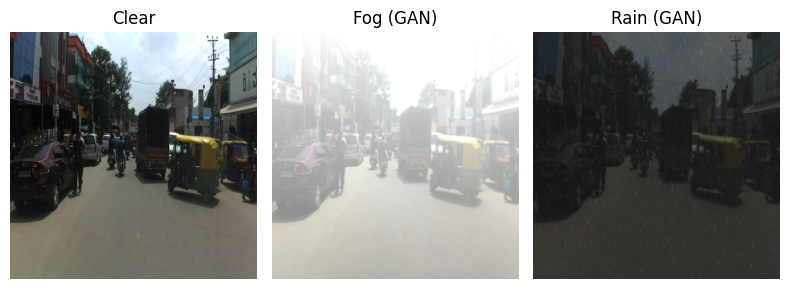

In [215]:
show_weather_results(test_img, out_fog, out_rain)